# Predicción de PM2.5 Beijing
### Introducción
El objetivo del proyecto fue predecir la concentración de partículas PM2.5 en Beijing utilizando variables meteorológicas y temporales. 

In [13]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, TweedieRegressor, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

## 1. Lectura, exploración y procesamiento

In [14]:
# Reading
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.sample(5)  # Revisar el tipos de datos y columnas presentes

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN
14015,14016,2011,8,7,23,NaN,24,25.0,1004.0,SE,27.28,0,0
41966,41967,2014,10,15,14,12.0,-5,23.0,1014.0,NW,48.72,0,0
9953,9954,2011,2,19,17,153.0,-9,10.0,1022.0,SE,3.13,0,0
22892,22893,2012,8,11,20,NaN,21,23.0,1006.0,NW,8.94,0,7
27723,27724,2013,3,1,3,6.0,-26,-2.0,1029.0,NW,195.34,0,0


In [15]:
# Cambiar fecha a float para los modelos
# Desestacionalizar las fechas

columnas_fecha = {
    'YEAR': 'year',
    'MONTH': 'month',
    'DAY': 'day',
    'HOUR': 'hour'
}
df['date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']].rename(columns=columnas_fecha))
df = df.drop(columns=['YEAR', 'MONTH', 'DAY', 'HOUR'])

# Hora (0-23) y el mes (1-12)
df['hora'] = df['date'].dt.hour
df['mes'] = df['date'].dt.month

# transformación a senos y cosenos)
# Para las horas (ciclo de 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# Para los meses (ciclo de 12 meses)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Borrar todas las columnas que no necesitamos
df = df.drop(columns=['hora', 'mes', 'date'])
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   PM25            41757 non-null  float64
 2   DEWPOINT        43824 non-null  int64  
 3   TEMP            43824 non-null  float64
 4   PRESION         43824 non-null  float64
 5   WIND_DIRECTION  43824 non-null  str    
 6   WIND_SPEED      43824 non-null  float64
 7   SNOW            43824 non-null  int64  
 8   RAIN            43824 non-null  int64  
 9   hora_sin        43824 non-null  float64
 10  hora_cos        43824 non-null  float64
 11  mes_sin         43824 non-null  float64
 12  mes_cos         43824 non-null  float64
dtypes: float64(8), int64(4), str(1)
memory usage: 4.3 MB


None

In [19]:
# Cleaning and Lags

# OJO! Esta programación es sin lags para PM2.5

# Lags inmediatos del clima (Pasado reciente)
variables_clima = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED', 'RAIN', 'SNOW']

for var in variables_clima:
    df[f'{var}_lag1'] = df[var].shift(1)
    df[f'{var}_lag2'] = df[var].shift(2)

# El Efecto Acumulado (Ventanas Móviles / Rolling Windows)
# Calculamos el promedio de las últimas 6 horas para capturar la tendencia sostenida
for var in variables_clima:
    # rolling(window=6) agrupa las últimas 6 filas, .mean() saca el promedio
    df[f'{var}_media_6h'] = df[var].rolling(window=6).mean()

# Si creen que algo más largo importa, pueden hacer una de 12 horas
for var in variables_clima:
    df[f'{var}_media_12h'] = df[var].rolling(window=12).mean()

# Limpieza final
# Como el lag 24 y la ventana de 12 horas necesitan datos del pasado, 
# las primeras 24 filas de todo el dataframe quedarán con NaN. Las borramos.
df_final = df.dropna().reset_index(drop=True)
# Por si quiero quedarme con los NAs de PM2.5 para imputarlos 
# Advertencia: pero no tiene mucho sentido porque se trata de la variable dependiente :/
# df_final = df.copy()
display(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 41757 entries, 0 to 41756
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NO                    41757 non-null  int64  
 1   PM25                  41757 non-null  float64
 2   DEWPOINT              41757 non-null  int64  
 3   TEMP                  41757 non-null  float64
 4   PRESION               41757 non-null  float64
 5   WIND_DIRECTION        41757 non-null  str    
 6   WIND_SPEED            41757 non-null  float64
 7   SNOW                  41757 non-null  int64  
 8   RAIN                  41757 non-null  int64  
 9   hora_sin              41757 non-null  float64
 10  hora_cos              41757 non-null  float64
 11  mes_sin               41757 non-null  float64
 12  mes_cos               41757 non-null  float64
 13  DEWPOINT_lag1         41757 non-null  float64
 14  DEWPOINT_lag2         41757 non-null  float64
 15  TEMP_lag1             41757 no

None

In [20]:
# Preprocesamiento: Escalado e Imputación por medio de Pipelines

# Pipeline para Números: Primero imputa con la mediana (aunque no hay nada que imputar), luego escala.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para Texto: Codificación, OneHotEncoding.
# handle_unknown='ignore' evita que el modelo falle si en el futuro aparece una dirección de viento nueva.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# make_column_selector, lo que hace: busca automáticamente las columnas según su tipo
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, make_column_selector(dtype_include=['float64', 'int64'])),
    ('cat', categorical_pipeline, make_column_selector(dtype_include=['object', 'category']))
], remainder='passthrough') # 'passthrough' por si hay alguna columna que no queramos tocar


# Train Test Split

# Separamos tus datos respetando el tiempo (Data Split)
corte = int(len(df_final) * 0.8)
X_train = df_final.iloc[:corte].drop(columns=['PM25'])
y_train = df_final.iloc[:corte]['PM25']

X_test = df_final.iloc[corte:].drop(columns=['PM25'])
y_test = df_final.iloc[corte:]['PM25']

## 2. Modelos Base y Regularización

In [21]:
# Preparando la visualización de los modelos

def evaluar_modelo_lineal(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los 3 gráficos estándar de evaluación 
    para cualquier modelo lineal dentro de un Pipeline.
    """
    # Hacemos las predicciones y calculamos los errores (residuos)
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones
    
    # Extraemos las entrañas del modelo (Coeficientes y Nombres)
    # pipeline[-1] accede a la última cajita (el algoritmo)
    # pipeline['prep'] accede a la primera cajita (el procesador de datos)
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()
    
    # Armamos la tabla y sacamos el Top 10 absoluto
    df_coef = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': modelo_puro.coef_})
    df_coef['Importancia_Abs'] = df_coef['Coeficiente'].abs()
    top_10 = df_coef.sort_values(by='Importancia_Abs', ascending=False).head(10)
    
    # Para crear los graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')
    
    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')
    
    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')
    
    # Gráfica C: Top 10 Coeficientes
    sns.barplot(
        x='Coeficiente', 
        y='Variable', 
        data=top_10, 
        ax=axes[2], 
        hue='Variable', 
        palette='viridis', 
        legend=False
    )
    axes[2].set_title('Top 10 Variables de Mayor Impacto')
    axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    plt.tight_layout()
    plt.show()

In [22]:
# Codigo para calcular el error (MSE, MAE, R²)
def calculo_errores(y, prediccion):
    """
    Función que genera los errores MSE, MAE, y R² para cualquiero modelo
    """
    mse = np.sqrt(mean_squared_error(y, prediccion))
    mae = mean_absolute_error(y, prediccion)
    r2 = r2_score(y, prediccion)
    return [mse, mae, r2]


Entrenado Lasso (tarda un poco)


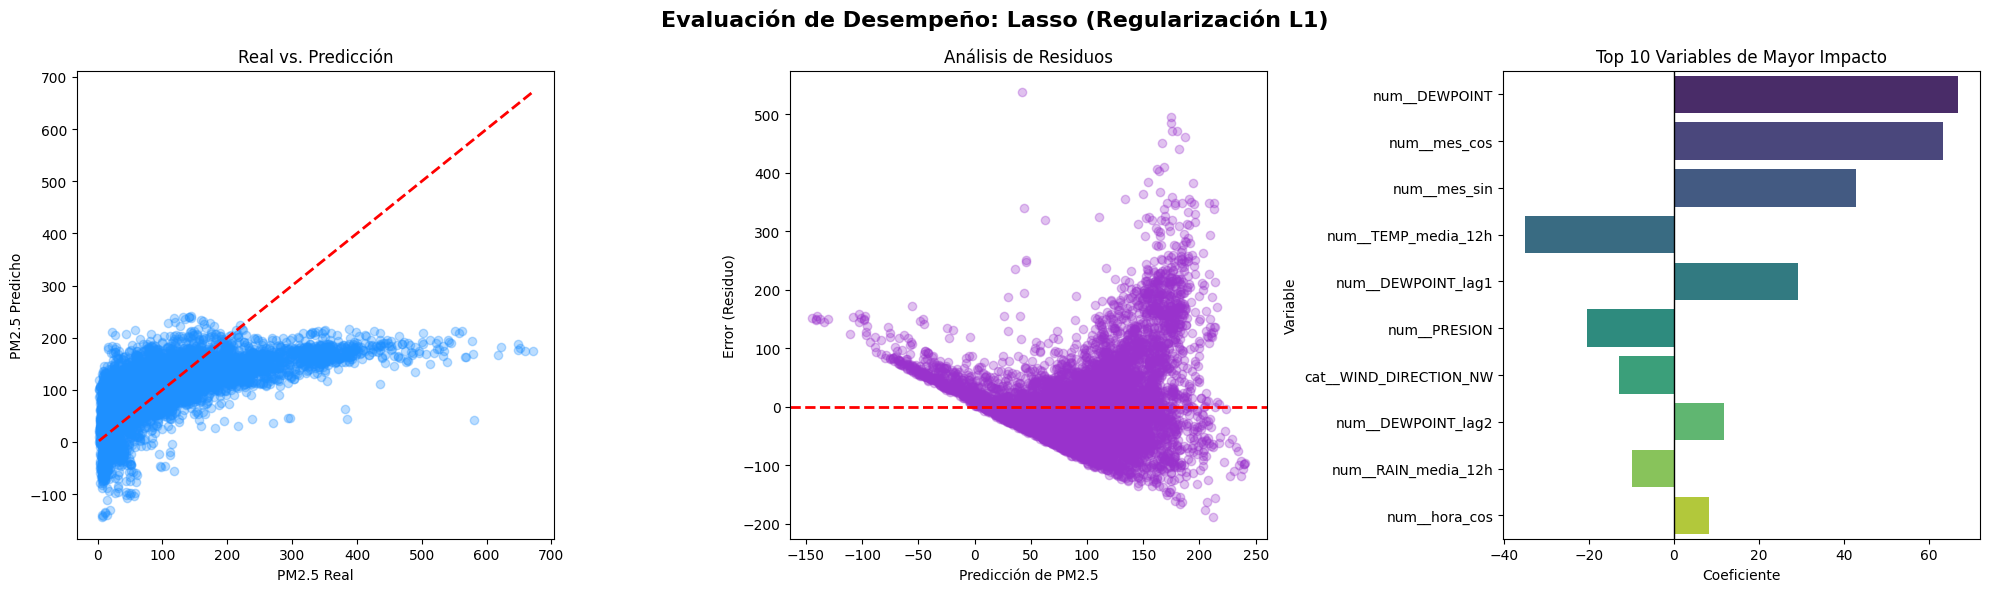

====== Lasso ======
RMSE: 72.08295875136194
MAE: 51.282338829543214
R² Score: 0.41544866169194605


In [23]:
# Lasso
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

modelo_final_lasso = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_lasso', LassoCV(cv=tscv, random_state=42, max_iter=10000))
])

# Entrenamos
print("Entrenado Lasso (tarda un poco)")
modelo_final_lasso.fit(X_train, y_train)

# Evaluamos
evaluar_modelo_lineal(modelo_final_lasso, X_test, y_test, "Lasso (Regularización L1)")

# Prediccion
predicciones_lasso = modelo_final_lasso.predict(X_test)

# Medición de errores
error_lasso = calculo_errores(y_test, predicciones_lasso)

print("====== Lasso ======")
print(f"RMSE: {error_lasso[0]}")
print(f"MAE: {error_lasso[1]}")
print(f"R² Score: {error_lasso[2]}")

Entrenando Ridge


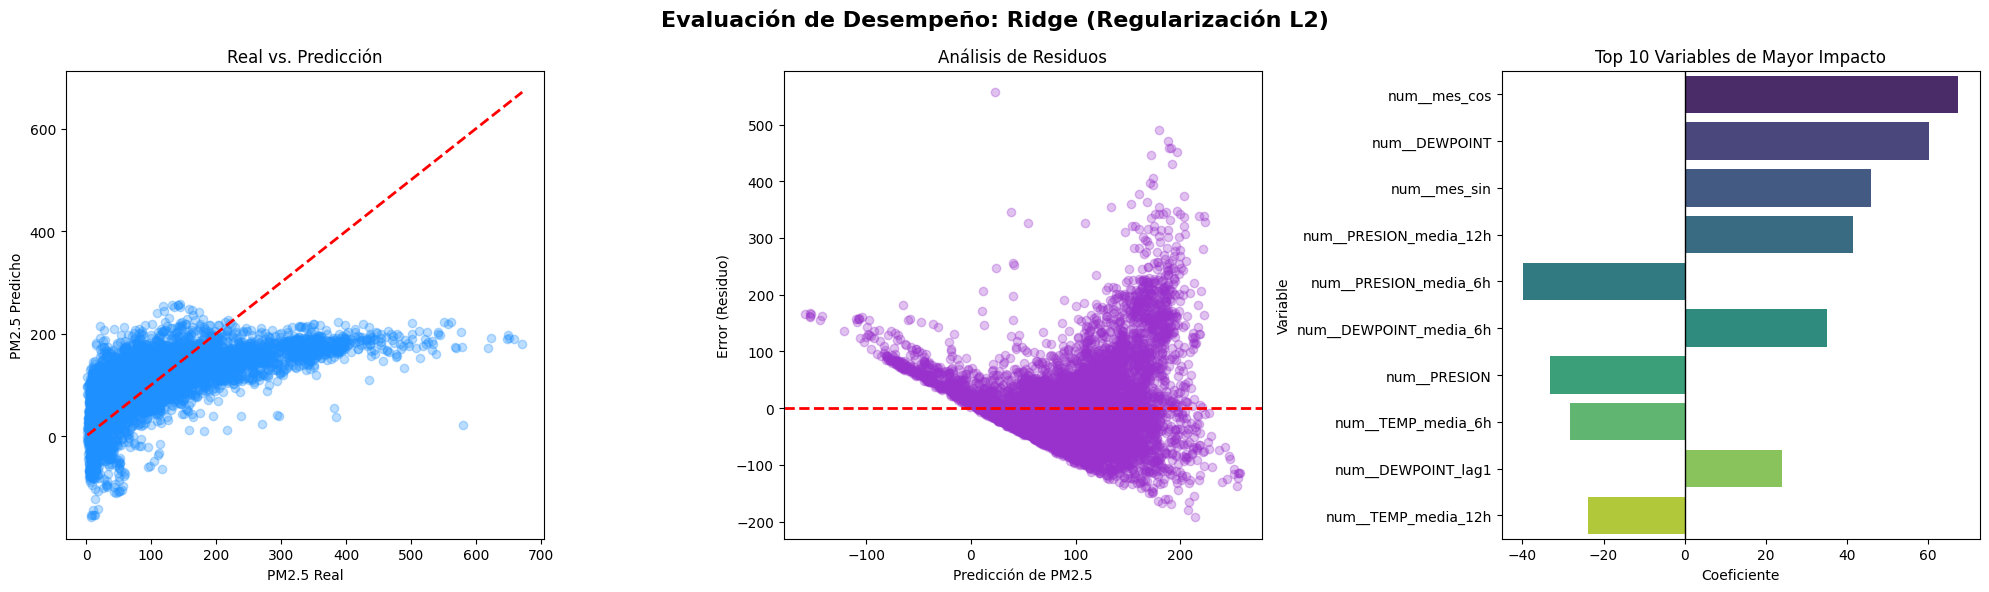


====== Ridge ======
RMSE: 71.6450454365543
MAE: 51.029326655286994
R² Score: 0.42252953779002256


In [9]:
# Ridge
modelo_final_ridge = Pipeline([
    ('preprocesamiento', preprocessor), ('modelo_ridge', RidgeCV(cv=5))
])

# Entrenamiento
print("Entrenando Ridge")
modelo_final_ridge.fit(X_train, y_train)

# Evaluamos Ridge
evaluar_modelo_lineal(modelo_final_ridge, X_test, y_test, "Ridge (Regularización L2)")

# Predicciónk
predicciones_ridge = modelo_final_ridge.predict(X_test)

# Medición de errores
error_ridge = calculo_errores(y_test, predicciones_ridge)

print("\n====== Ridge ======")
print(f"RMSE: {error_ridge[0]}")
print(f"MAE: {error_ridge[1]}")
print(f"R² Score: {error_ridge[2]}")

Entrenando GLM


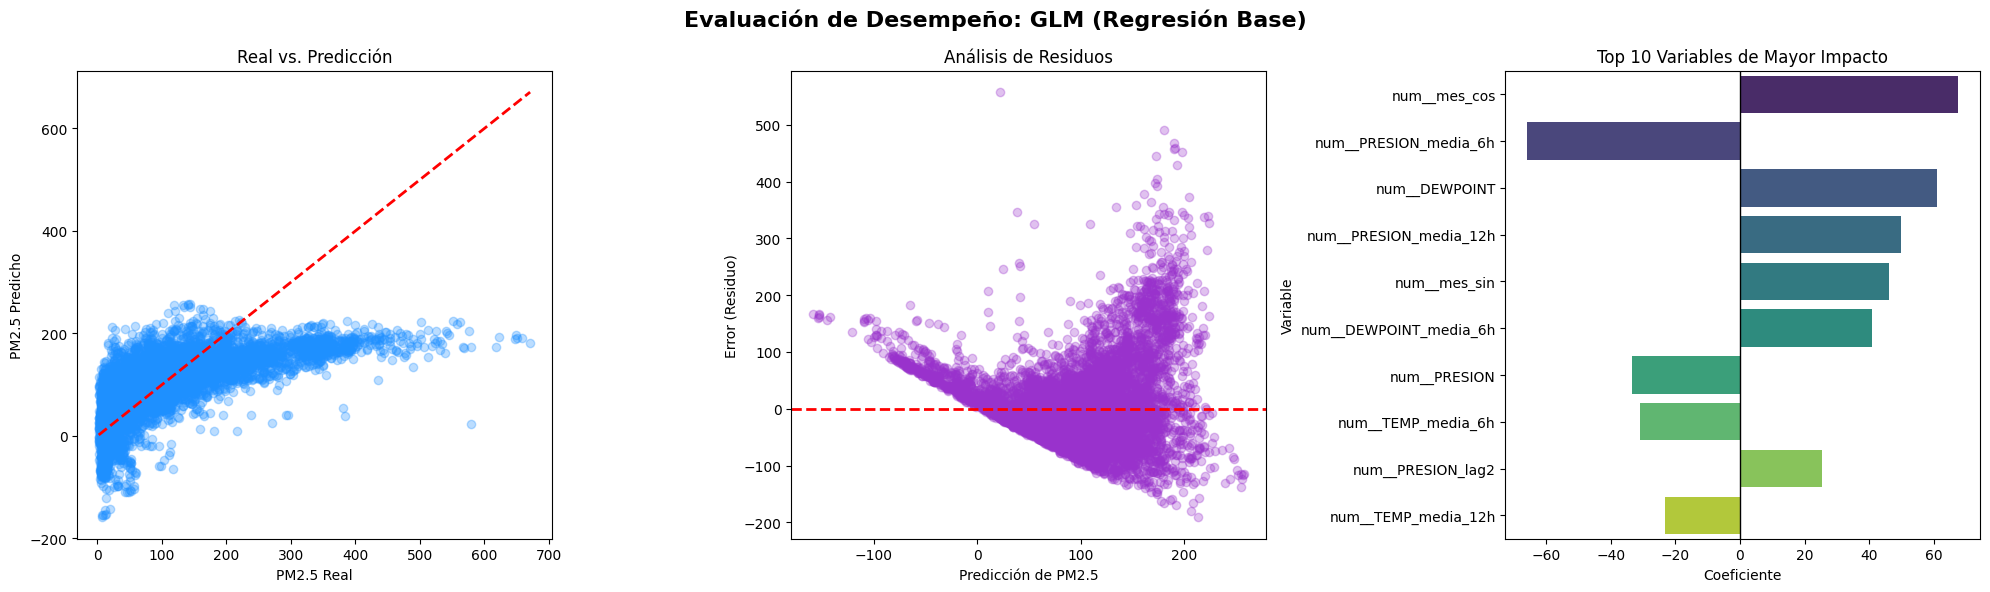


====== GLM ======
RMSE: 71.6414972177379
MAE: 51.05503590791764
R² Score: 0.42258673478974007


In [10]:
# GLM 
glm_normal = LinearRegression()

modelo_final_glm = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_glm_normal', glm_normal)
])

# Entrenamiento
print("Entrenando GLM")
modelo_final_glm.fit(X_train, y_train)

# Evaluamos el GLM
evaluar_modelo_lineal(modelo_final_glm, X_test, y_test, "GLM (Regresión Base)")

# Prediccion
predicciones_glm = modelo_final_glm.predict(X_test)

# Medición de error
error_glm = calculo_errores(y_test, predicciones_glm)

print("\n====== GLM ======")
print(f"RMSE: {error_glm[0]}")
print(f"MAE: {error_glm[1]}")
print(f"R² Score: {error_glm[2]}")

In [11]:
# Entramos al pipeline y extraemos el modelo entrenado de la última posición [-1]
lasso_entrenado = modelo_final_lasso[-1]
ridge_entrenado = modelo_final_ridge[-1]
glm_entrenado   = modelo_final_glm[-1]

# Extraemos los nombres de las variables que salieron del preprocesamiento
# (Nota: OneHotEncoder crea nombres nuevos para las categorías, así los recuperamos)
nombres_features = modelo_final_lasso['preprocesamiento'].get_feature_names_out()

# Creamos el DataFrame de coeficientes
df_coeficientes = pd.DataFrame({
    'Variable': nombres_features,
    'Coef_GLM_Base': glm_entrenado.coef_,
    'Coef_Lasso': lasso_entrenado.coef_,
    'Coef_Ridge': ridge_entrenado.coef_
})

# Agregamos una columna con el valor absoluto de Lasso para ordenar por importancia
df_coeficientes['Importancia'] = df_coeficientes['Coef_Lasso'].abs()
df_coeficientes_ordenados = df_coeficientes.sort_values(by='Importancia', ascending=False).drop(columns=['Importancia'])

print("== Coeficientes de los modelos ==")
display(df_coeficientes_ordenados)

== Coeficientes de los modelos ==


,Variable,Coef_GLM_Base,Coef_Lasso,Coef_Ridge
10,num__mes_cos,67.653797,67.525378,67.424976
1,num__DEWPOINT,60.991611,62.009121,60.305764
9,num__mes_sin,46.029167,45.989770,45.879760
3,num__PRESION,-33.503387,-36.925531,-33.262071
31,num__PRESION_media_12h,49.816091,34.603615,41.413968
23,num__DEWPOINT_media_6h,40.788525,27.282030,35.049587
24,num__TEMP_media_6h,-30.869810,-26.653343,-28.158177
11,num__DEWPOINT_lag1,22.292507,24.106984,23.893547
30,num__TEMP_media_12h,-23.339837,-23.397468,-23.769272
25,num__PRESION_media_6h,-65.907549,-19.336941,-39.758799


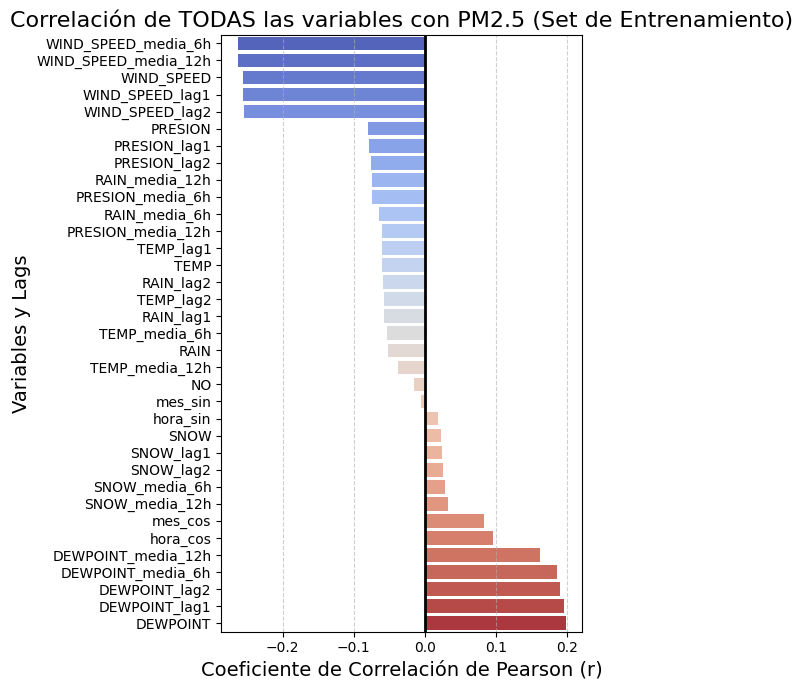

In [12]:
# Analisis de Correlaciones

# Unimos tu guía de estudio (X_train y y_train) temporalmente
datos_entrenamiento = pd.concat([X_train, y_train], axis=1)

# numeric_only=True ignora la columna de texto (viento) automáticamente
correlaciones_pm25 = datos_entrenamiento.corr(numeric_only=True)['PM25'].drop('PM25')

# Ordenamos TODAS las variables (sin recortar nada)
correlaciones_ordenadas = correlaciones_pm25.sort_values(ascending=True)

plt.figure(figsize=(6, 7))

sns.barplot(
    x=correlaciones_ordenadas.values, 
    y=correlaciones_ordenadas.index, 
    hue=correlaciones_ordenadas.index, # Asignamos 'y' a 'hue' como pide la advertencia
    palette="coolwarm", 
    legend=False                       # Apagamos la leyenda automática
)

plt.title('Correlación de TODAS las variables con PM2.5 (Set de Entrenamiento)', fontsize=16)
plt.xlabel('Coeficiente de Correlación de Pearson (r)', fontsize=14)
plt.ylabel('Variables y Lags', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Resumen

Con los resultados observamos que la regularización (L1 o L2) no ayudó aquí. Ridge y Lasso no mejoraron sobre la regresión lineal base porque el problema no es de overfitting en los coeficientes — el problema es que la relación simplemente no es lineal.La regularización (L1 o L2) no ayudó aquí. Ridge y Lasso no mejoraron sobre la regresión lineal base porque el problema no es de overfitting en los coeficientes — el problema es que la relación simplemente no es lineal.

## 3. Modelos de Ensamble y Redes

In [23]:
# k-folds (Cross Validation) y Calculo de Errores (MSE, MAE, R²) 
# para los modelos de ensamble y redes

def calculo_errores_ensamble(y, prediccion, modelo):
    """
    Función que genera los errores MSE, MAE, y R² para cualquiero modelo
    """
    mse = np.sqrt(mean_squared_error(y, prediccion))
    mae = mean_absolute_error(y, prediccion)
    r2 = r2_score(y, prediccion)
    puntajes_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_cv = np.sqrt(-puntajes_cv)
    return [mse, mae, r2, rmse_cv]


In [24]:
# Funcion para graficar los resultados de los modelos de arboles de desición

def evaluar_modelo_arbol(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los gráficos para modelos basados
    en árboles (Random Forest, XGBoost, AdaBoost).
    """
    # Predicciones y residuos
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones
    
    # Extraemos el modelo y los nombres de las variables
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()
    
    # Usamos .feature_importances_ en lugar de .coef_ 
    df_importancia = pd.DataFrame({
        'Variable': nombres_variables, 
        'Importancia': modelo_puro.feature_importances_
    })
    
    # Ordenamos para sacar el Top 10
    top_10 = df_importancia.sort_values(by='Importancia', ascending=False).head(10)
    
    # Canvas de los 3 graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')
    
    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')
    
    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')
    
    # Gráfica C: Top 10 Importancia
    sns.barplot(
        x='Importancia', 
        y='Variable', 
        data=top_10, 
        ax=axes[2], 
        hue='Variable', 
        palette='magma', 
        legend=False
    )
    axes[2].set_title('Top 10 Variables más Importantes')
    
    plt.tight_layout()
    plt.show()

Entrenando XGBoost
====== XGBoost ======
RMSE: 68.60852987694213
MAE: 51.16152117291815
R² Score: 0.4704418248204112

==== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ====
[71.16106844 68.29112415 65.71963161 78.36987229 79.6023986 ]
RMSE Promedio: 72.6288
Desviación estándar: 5.4827



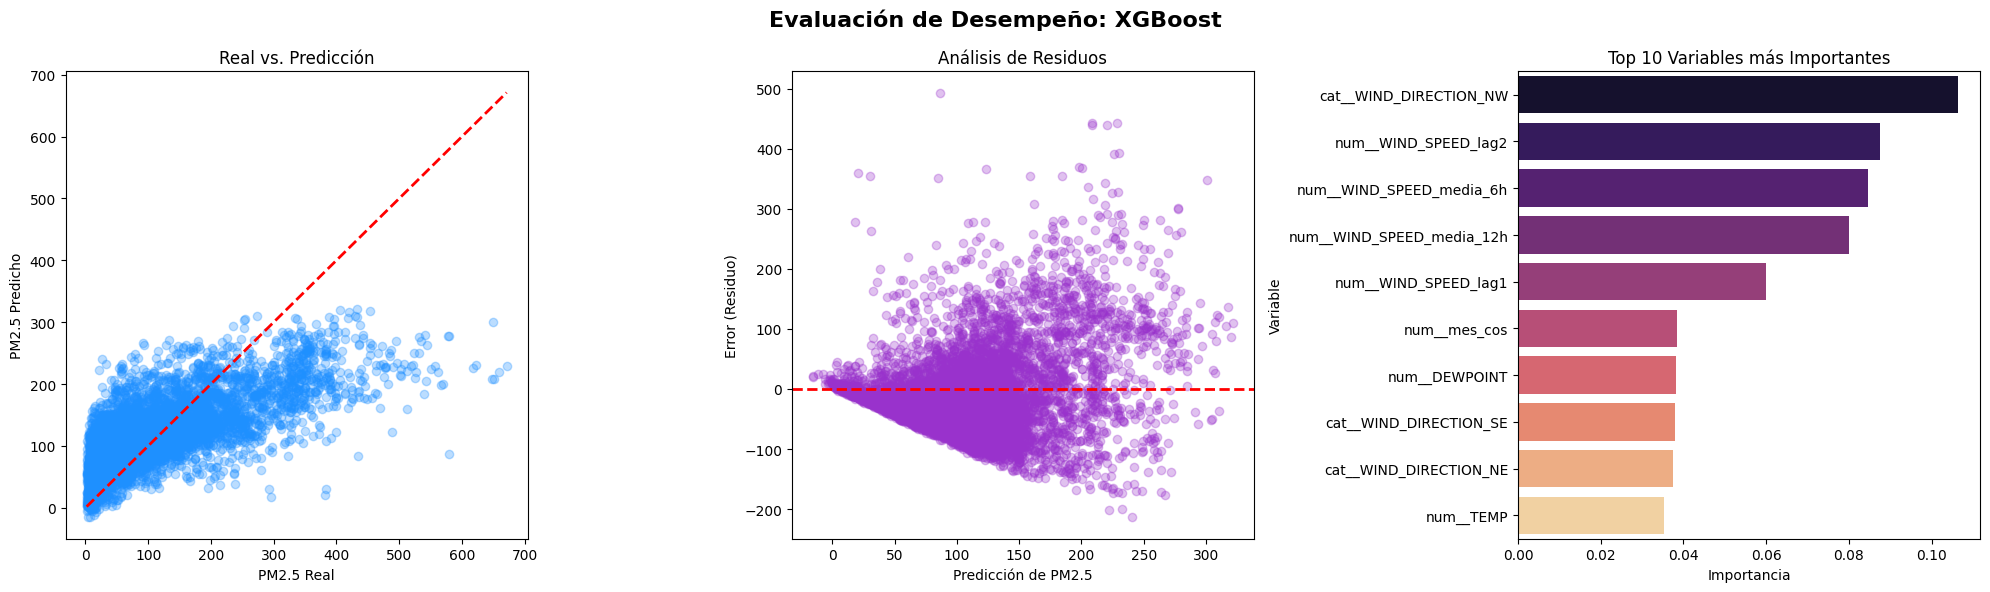

In [25]:
# XGBoost

# learning_rate=0.1 controla qué tan rápido aprende de los errores de los árboles anteriores
# max_depth=6 limita el tamaño de cada árbol para evitar sobreajuste (overfitting)

# modelo_xgb = XGBRegressor(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6,
#     random_state=42,
#     n_jobs=-1
# )

modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Pipe
modelo_final_xgb = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_xgb', modelo_xgb)
])

# Entrenando el modelo
print("Entrenando XGBoost")
modelo_final_xgb.fit(X_train, y_train)

# Predicciones
predicciones_xgb = modelo_final_xgb.predict(X_test)

# Evaluar predicciones con la funcion `calculo_errores`
error_xgb = calculo_errores_ensamble(y_test, predicciones_xgb, modelo_final_xgb)

print("====== XGBoost ======")
print(f"RMSE: {error_xgb[0]}")
print(f"MAE: {error_xgb[1]}")
print(f"R² Score: {error_xgb[2]}")
print("\n==== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ====")
print(error_xgb[3])
print(f"RMSE Promedio: {error_xgb[3].mean():.4f}")
print(f"Desviación estándar: {error_xgb[3].std():.4f}\n")

# graficar resultados
evaluar_modelo_arbol(modelo_final_xgb, X_test, y_test, "XGBoost")

Entrenando RF
====== Random Forest ======
RMSE: 77.38342005413544
MAE: 59.62963686657026
R² Score: 0.32632056529453324

=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===
[62.38621211 71.70144552 69.94701357 81.40447826 80.67295823]
RMSE Promedio: 73.2224
Desviación estándar: 7.1123



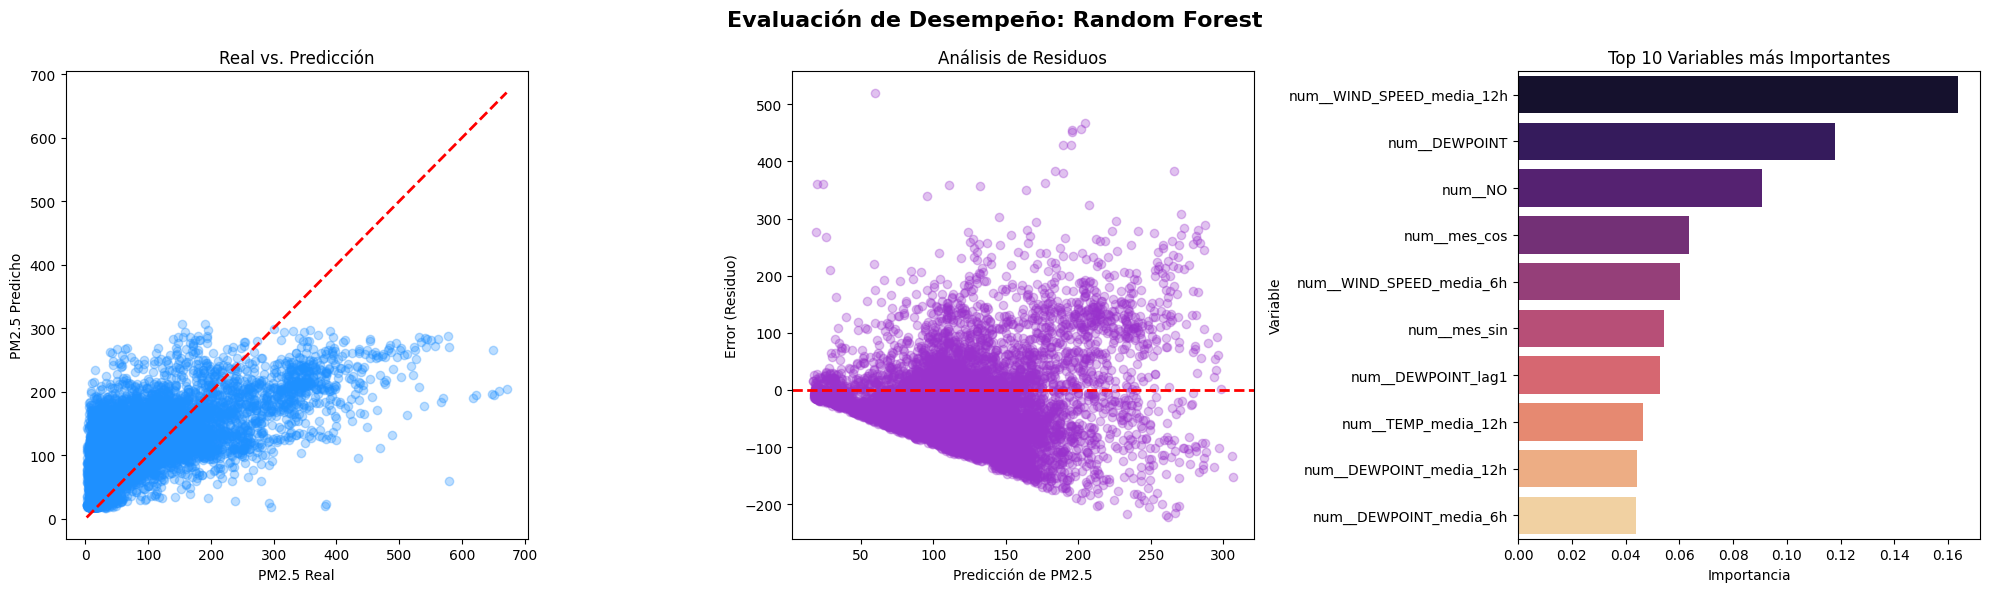

In [26]:
# Random Forest

# n_estimators=100 significa que plantaremos 100 árboles de decisión
# n_jobs=-1 es para usar todos los nucleos del procesador

# bosque = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Random Forest más conservador
bosque = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

# lo conectamos al Pipe
modelo_final_rf = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_rf', bosque)
])

# Entrenamiento
print("Entrenando RF")
modelo_final_rf.fit(X_train, y_train)

# predicciones y medir el error
predicciones_rf = modelo_final_rf.predict(X_test)

error_rf = calculo_errores_ensamble(y_test, predicciones_rf, modelo_final_rf)

print("====== Random Forest ======")
print(f"RMSE: {error_rf[0]}")
print(f"MAE: {error_rf[1]}")
print(f"R² Score: {error_rf[2]}")
print("\n=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===")
print(error_rf[3])
print(f"RMSE Promedio: {error_rf[3].mean():.4f}")
print(f"Desviación estándar: {error_rf[3].std():.4f}\n")

# Visualizar resultados
evaluar_modelo_arbol(modelo_final_rf, X_test, y_test, "Random Forest")

Entrenando AdaBoost
====== AdaBoost ======
RMSE: 78.69325633272703
MAE: 62.415982826318334
R² Score: 0.30332137888726185

===== Resultados de la Validación Cruzada (RMSE en 5 pliegues) =====
[73.8036911  77.12722534 77.53218268 87.23339828 76.80742408]
RMSE Promedio: 78.5008
Desviación estándar: 4.5610



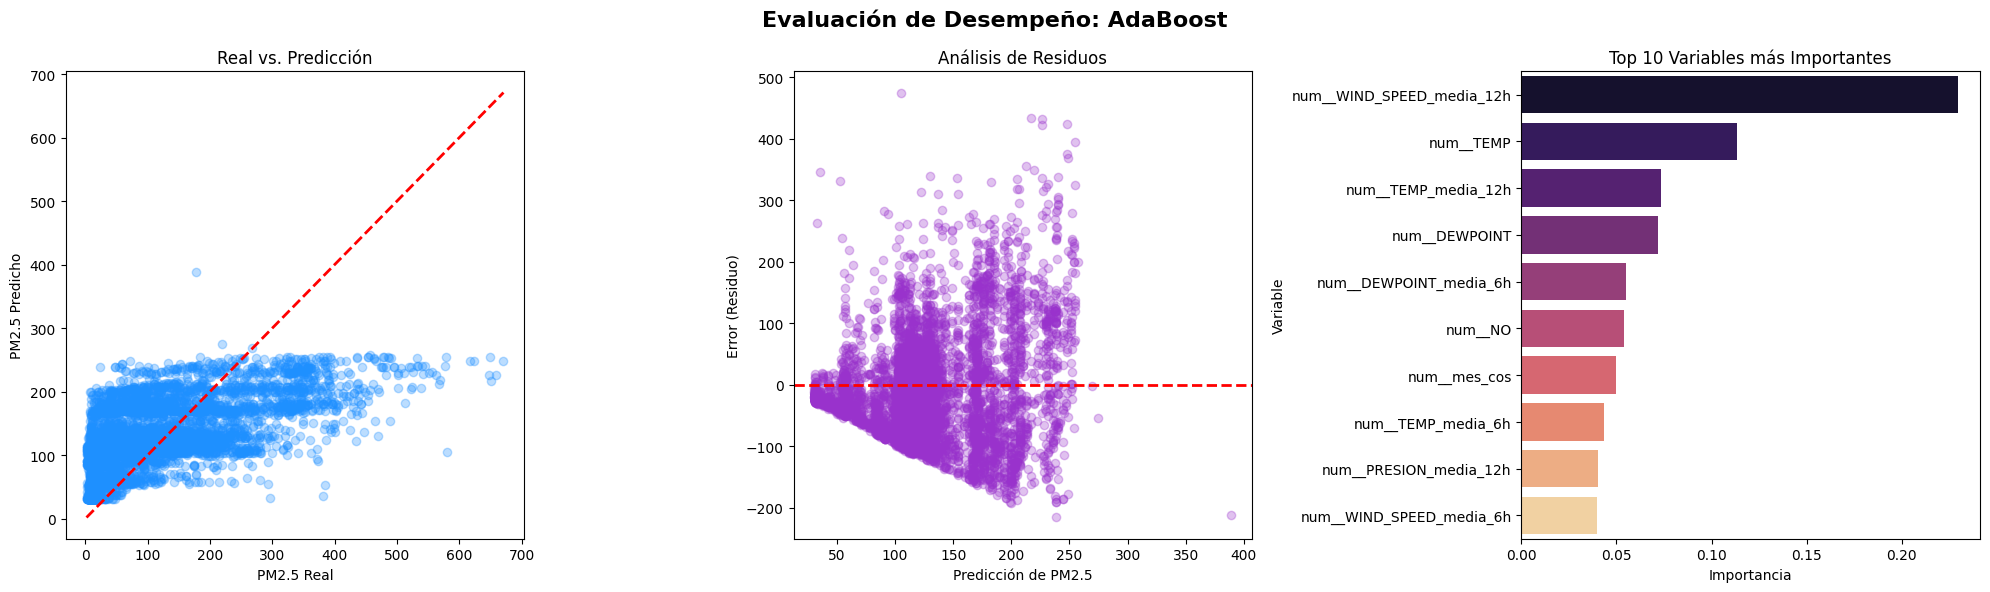

In [17]:
# AdaBoost

# Usamos árboles de decisión pequeños (max_depth=4) como modelo base
modelo_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)

# Conectarlo al Pipeline
modelo_final_ada = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_ada', modelo_ada)
])

# Entrenamiento
print("Entrenando AdaBoost")
modelo_final_ada.fit(X_train, y_train)

# Predicción
predicciones_ada = modelo_final_ada.predict(X_test)

# Medición del error
error_ada = calculo_errores_ensamble(y_test, predicciones_ada, modelo_final_ada)

print("====== AdaBoost ======")
print(f"RMSE: {error_ada[0]}")
print(f"MAE: {error_ada[1]}")
print(f"R² Score: {error_ada[2]}")
print("\n===== Resultados de la Validación Cruzada (RMSE en 5 pliegues) =====")
print(error_ada[3])
print(f"RMSE Promedio: {error_ada[3].mean():.4f}")
print(f"Desviación estándar: {error_ada[3].std():.4f}\n")

# Visualizar con la funcion evaluar_modelo_arbol
evaluar_modelo_arbol(modelo_final_ada, X_test, y_test, "AdaBoost")

Entrenando MLP... (es el que más tarda)

====== MLP (Perceptron Multicapa) ======
RMSE: 112.74339176199871
MAE: 84.0677291546873
R² Score: -0.43001186827632365

=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===
[84.75771278 67.20815104 76.02478706 82.3385401  70.16789093]
RMSE Promedio: 76.0994
Desviación estándar: 6.7548



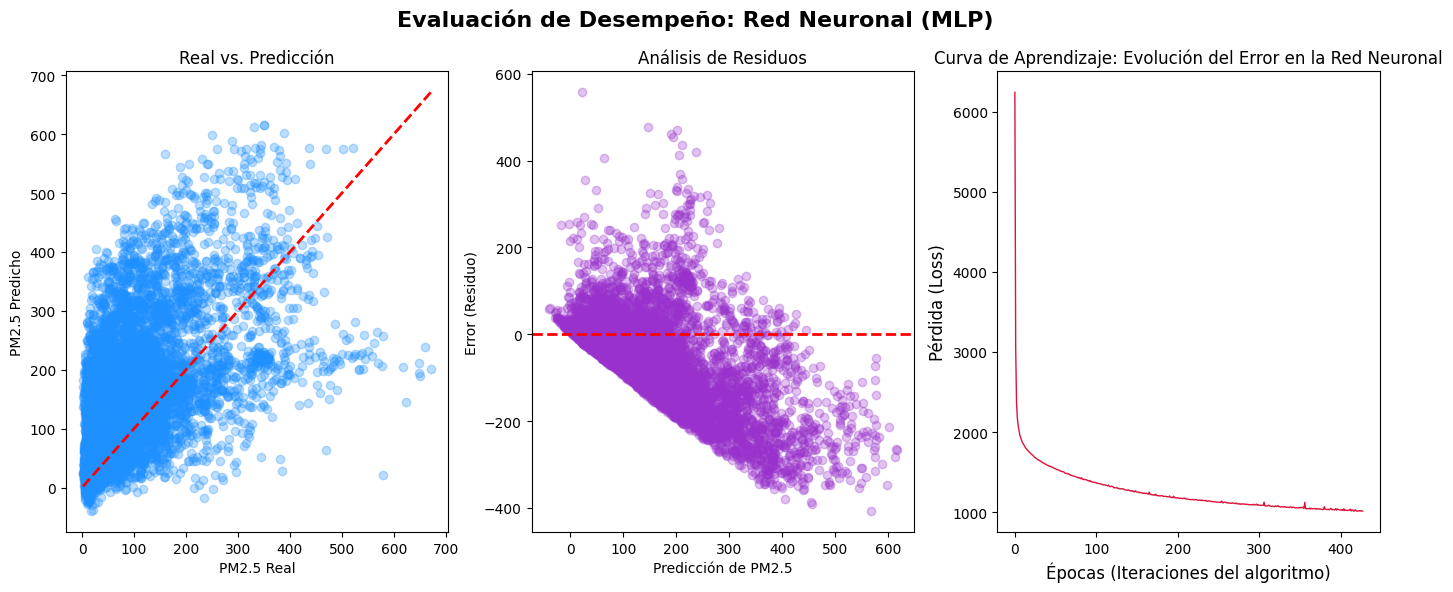

In [18]:
# Red Neuronal (MLP)

# hidden_layer_sizes=(64, 32) crea dos capas con 64 y 32 neuronas
# modificar `max_iter` para que aprenda más o menos epocas
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=1000, # epocas
    random_state=42
)

#  Conectarlo al Pipeline
modelo_final_mlp = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_mlp', modelo_mlp)
])

# Entrenamiento
print("Entrenando MLP... (Aguas! es el que más tarda)")
modelo_final_mlp.fit(X_train, y_train)

# Predicciones y medición de errores
predicciones_mlp = modelo_final_mlp.predict(X_test)

error_mlp = calculo_errores_ensamble(y_test, predicciones_mlp, modelo_final_mlp)

print("\n====== MLP (Perceptron Multicapa) ======")
print(f"RMSE: {error_mlp[0]}")
print(f"MAE: {error_mlp[1]}")
print(f"R² Score: {error_mlp[2]}")
print("\n=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===")
print(error_mlp[3])
print(f"RMSE Promedio: {error_mlp[3].mean():.4f}")
print(f"Desviación estándar: {error_mlp[3].std():.4f}\n")

# ---------------------------------------------------------------
# Visualización exclusiva para MLP (Sin importancia de variables)
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Evaluación de Desempeño: Red Neuronal (MLP)', fontsize=16, fontweight='bold')

# Gráfica A: Real vs Predicho
axes[0].scatter(y_test, predicciones_mlp, alpha=0.3, color='dodgerblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_title('Real vs. Predicción')
axes[0].set_xlabel('PM2.5 Real')
axes[0].set_ylabel('PM2.5 Predicho')

# Gráfica B: Residuos
residuos_mlp = y_test - predicciones_mlp
axes[1].scatter(predicciones_mlp, residuos_mlp, alpha=0.3, color='darkorchid')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Análisis de Residuos')
axes[1].set_xlabel('Predicción de PM2.5')
axes[1].set_ylabel('Error (Residuo)')


# GRáfica C: Curva de Aprendizaje
# MLPRegressor es el ultimo
red_neuronal = modelo_final_mlp[-1]
# Extraemos el historial de errores ( esto es la curva de aprendizaje)
historial_errores = red_neuronal.loss_curve_
axes[2].plot(historial_errores, color='crimson', linewidth=1)
axes[2].set_title('Curva de Aprendizaje: Evolución del Error en la Red Neuronal')
axes[2].set_xlabel('Épocas (Iteraciones del algoritmo)', fontsize=12)
axes[2].set_ylabel('Pérdida (Loss)', fontsize=12)

plt.tight_layout()
plt.show()

#### Resultados
La arquitectura del modelo importa, pero los hiperparámetros importan igual o más. XGBoost sin tuning fue el peor modelo del proyecto; con tuning fue el mejor. La capacidad de generalización temporal requiere restringir la complejidad del modelo explícitamente.

## 4. Optimización de Funciones de perdida

In [24]:
# Optimización MAE vs MSE

# Entrenamos el Modelo 1: Su único objetivo en la vida es minimizar el MSE
modelo_mse = GradientBoostingRegressor(loss='squared_error', random_state=42)
pipe_mse = Pipeline(steps=[('preprocesamiento', preprocessor), ('modelo', modelo_mse)])
pipe_mse.fit(X_train, y_train)
pred_mse = pipe_mse.predict(X_test)

# Entrenamos el Modelo 2: Su único objetivo en la vida es minimizar el MAE
modelo_mae = GradientBoostingRegressor(loss='absolute_error', random_state=42)
pipe_mae = Pipeline(steps=[('preprocesamiento', preprocessor), ('modelo', modelo_mae)])
pipe_mae.fit(X_train, y_train)
pred_mae = pipe_mae.predict(X_test)

# Calculamos cómo le fue a cada uno en su propia métrica y en la del rival
print("MAE vs. MSE")
error_mae = calculo_errores(y_test, pred_mae)
error_mse = calculo_errores(y_test, pred_mse)

print("\n====== MAE ======")
print(f"RMSE: {error_mae[0]}")
print(f"MAE: {error_mae[1]}")
print(f"R² Score: {error_mae[2]}")

print("\n====== MSE ======")
print(f"RMSE: {error_mse[0]}")
print(f"MAE: {error_mse[1]}")
print(f"R² Score: {error_mse[2]}")


MAE vs. MSE

====== MAE ======
RMSE: 70.65992660040904
MAE: 46.15669544910933
R² Score: 0.43830078892839786

====== MSE ======
RMSE: 100.30673615963603
MAE: 83.24331010001315
R² Score: -0.13192499115822942


#### Resultados
El dataset de Beijing PM2.5 contiene valores extremos que distorsionan el entrenamiento bajo MSE. El modelo optimizado por MAE resultó más robusto porque su función de pérdida no amplifica el efecto de estos outliers, produciendo mejores métricas generales.

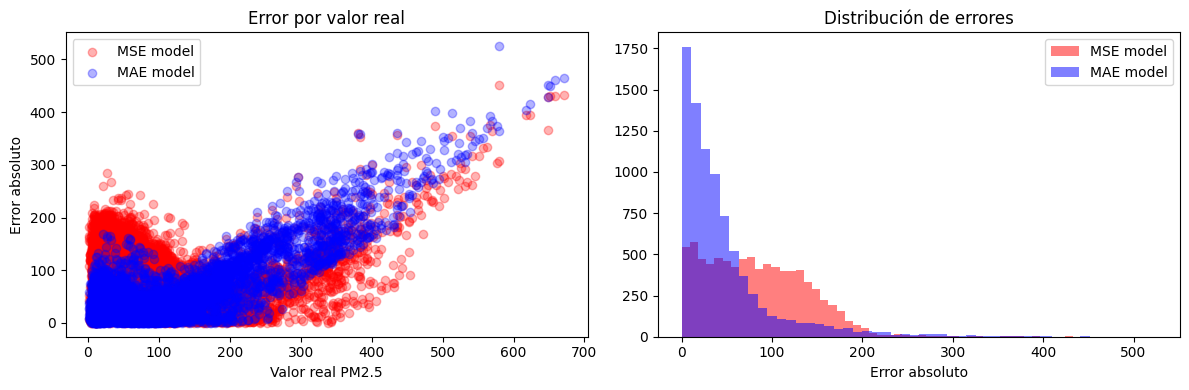

In [22]:
plt.figure(figsize=(12, 4))

errores_mse = np.abs(y_test - pred_mse)
errores_mae = np.abs(y_test - pred_mae)

plt.subplot(1, 2, 1)
plt.scatter(y_test, errores_mse, alpha=0.3, color='red', label='MSE model')
plt.scatter(y_test, errores_mae, alpha=0.3, color='blue', label='MAE model')
plt.xlabel('Valor real PM2.5')
plt.ylabel('Error absoluto')
plt.title('Error por valor real')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(errores_mse, bins=50, alpha=0.5, color='red', label='MSE model')
plt.hist(errores_mae, bins=50, alpha=0.5, color='blue', label='MAE model')
plt.xlabel('Error absoluto')
plt.title('Distribución de errores')
plt.legend()

plt.tight_layout()
plt.show()